In [2]:
import pandas as pd
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, BertForSequenceClassification
from sklearn.metrics import classification_report
from tqdm import tqdm

In [5]:
train_df = pd.read_csv("../data_labelling/train_labeled.csv")
val_df   = pd.read_csv("../data_labelling/val_labeled.csv")
test_df  = pd.read_csv("../data_labelling/test_labeled.csv")
pseudo_pool  = pd.read_csv("../splitting/pseudo_pool.csv")

for df in [train_df, val_df, test_df]:
    df["label"] = df["label"].astype(int)

In [6]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained("./model1_manual")
teacher_model = BertForSequenceClassification.from_pretrained(
    "./model1_manual",
    num_labels=3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model.to(device)
teacher_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [7]:
def generate_pseudo_labels(df, model, tokenizer, device, max_len=128):
    texts = df["cleaned_text"].tolist()

    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=1)

    df["pseudo_label"] = torch.argmax(probs, dim=1).cpu().numpy()
    df["confidence"]   = torch.max(probs, dim=1).values.cpu().numpy()

    return df

In [8]:
pseudo_labeled = generate_pseudo_labels(
    pseudo_pool,
    teacher_model,
    tokenizer,
    device
)

In [10]:
pseudo_train = pseudo_labeled[["cleaned_text", "pseudo_label"]]
pseudo_train.columns = ["cleaned_text", "label"]

train_model3 = pd.concat(
    [train_df[["cleaned_text", "label"]], pseudo_train],
    ignore_index=True
)

print("Train Model 3 size:", len(train_model3))
print(train_model3["label"].value_counts())

Train Model 3 size: 1500
label
0    802
2    392
1    306
Name: count, dtype: int64


In [11]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["cleaned_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [12]:
train_ds = SentimentDataset(train_model3, tokenizer)
val_ds   = SentimentDataset(val_df, tokenizer)
test_ds  = SentimentDataset(test_df, tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

In [13]:
model3 = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
).to(device)

optimizer = AdamW(model3.parameters(), lr=2e-5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}
        loss = model(**batch).loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            total_loss += model(**batch).loss.item()

    return total_loss / len(loader)

In [16]:
EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", train_epoch(model3, train_loader))
    print("Val Loss  :", eval_epoch(model3, val_loader))


Epoch 1


100%|██████████| 94/94 [01:05<00:00,  1.43it/s]


Train Loss: 0.8139490843453305
Val Loss  : 0.7210526317358017

Epoch 2


100%|██████████| 94/94 [01:06<00:00,  1.42it/s]


Train Loss: 0.42039476295417927
Val Loss  : 0.9203549772500992

Epoch 3


100%|██████████| 94/94 [01:06<00:00,  1.41it/s]


Train Loss: 0.1681428817001746
Val Loss  : 1.233380889520049


In [17]:
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            labels.extend(batch["labels"].numpy())
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

    return np.array(preds), np.array(labels)

In [ ]:
y_pred, y_true = evaluate(model3, test_loader)

print(classification_report(
    
    y_true,
    y_pred,
    target_names=["Negatif", "Netral", "Positif"]
))

              precision    recall  f1-score   support

     Negatif       0.80      0.73      0.76       130
      Netral       0.79      0.43      0.56        60
     Positif       0.51      0.83      0.63        60

    accuracy                           0.68       250
   macro avg       0.70      0.67      0.65       250
weighted avg       0.73      0.68      0.68       250



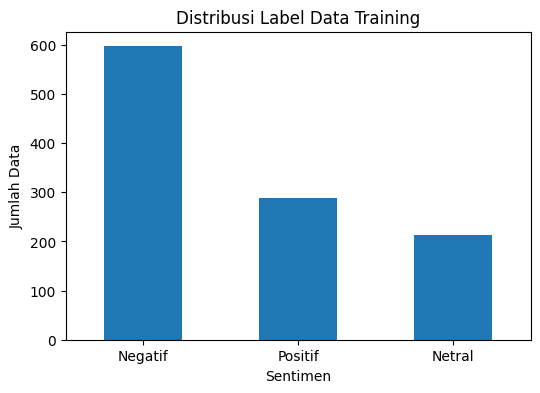

In [21]:
import matplotlib.pyplot as plt

label_map = {0: "Negatif", 1: "Netral", 2: "Positif"}

train_df["label_name"] = train_df["label"].map(label_map)

plt.figure(figsize=(6,4))
train_df["label_name"].value_counts().plot(kind="bar")
plt.title("Distribusi Label Data Training")
plt.ylabel("Jumlah Data")
plt.xlabel("Sentimen")
plt.xticks(rotation=0)
plt.show()

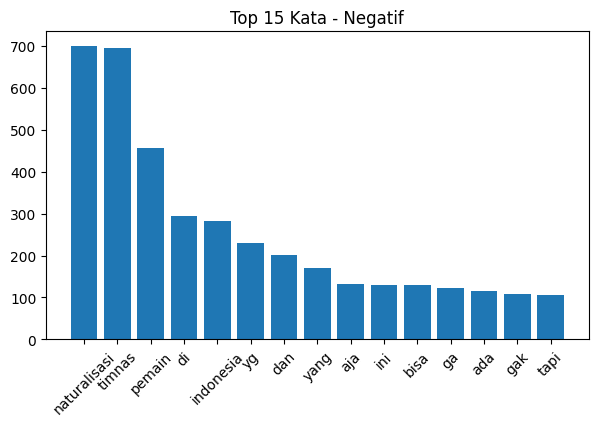

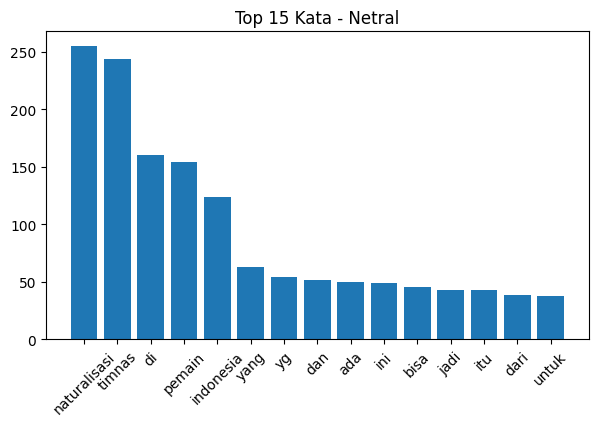

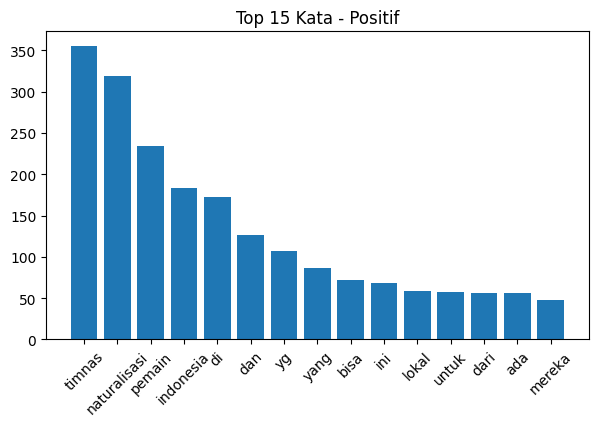

In [22]:
from collections import Counter
import re

def get_top_words(df, label, top_n=15):
    texts = df[df["label"] == label]["cleaned_text"]
    words = []
    for text in texts:
        words.extend(re.findall(r"\b\w+\b", text.lower()))
    return Counter(words).most_common(top_n)

for label, name in label_map.items():
    top_words = get_top_words(train_df, label)
    words, counts = zip(*top_words)

    plt.figure(figsize=(7,4))
    plt.bar(words, counts)
    plt.title(f"Top {len(words)} Kata - {name}")
    plt.xticks(rotation=45)
    plt.show()

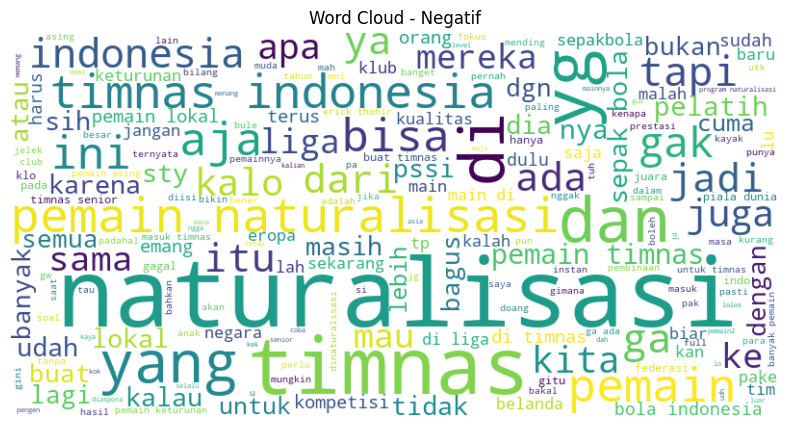

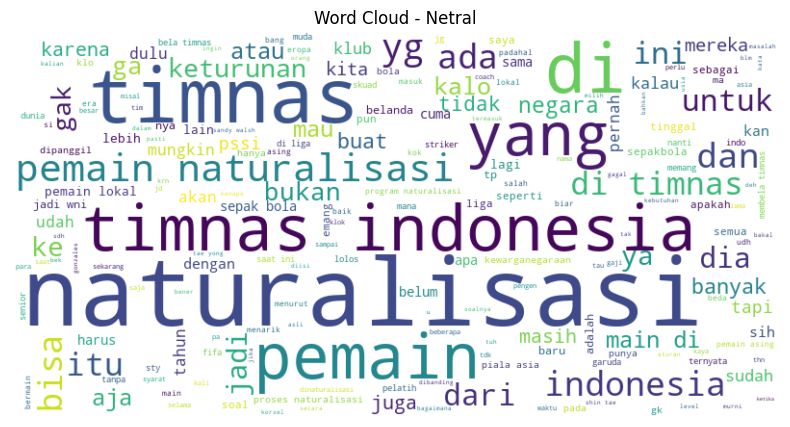

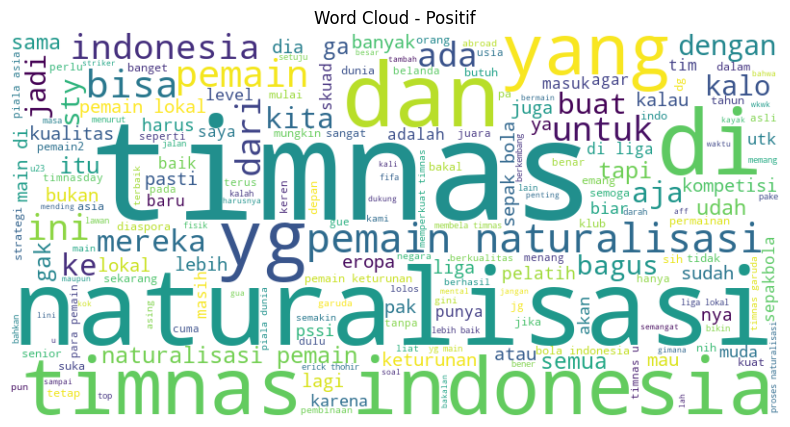

In [23]:
from wordcloud import WordCloud

for label, name in label_map.items():
    text = " ".join(train_df[train_df["label"] == label]["cleaned_text"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {name}")
    plt.show()